# CfD Hedge Model — Part 1: Core Model
Replicates Excel-style CfD position tracking in clean Python.
Covers: position definition, settlement calculation, negative price handling, hedge ratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from dataclasses import dataclass, field
from typing import List

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print('Libraries loaded.')

Libraries loaded.


In [2]:
# CfD Position dataclass
# A Contract for Difference gives the holder the difference between a strike price and a reference market price, scaled by volume.
# Long = buyer of CfD (receives if ref > strike), Short = seller.

@dataclass
class CfDPosition:
    name: str
    strike_price: float      # £/MWh — agreed contract price
    volume_mwh_per_month: float        # MWh per month — contract volume
    direction: str           # 'long' or 'short'
    months_remaining: int = 180   # Remaining contract duration (15 years = 180 months)

    def monthly_settlement(self, reference_price: float) -> float:
        """
        Calculate CfD settlement for ONE month only.
        Long position: receives (ref - strike) * volume
        Short position: pays  (ref - strike) * volume
        Negative reference prices are fully supported.
        """
        diff = reference_price - self.strike_price
        payout = diff * self.volume_mwh_per_month
        return payout if self.direction == 'long' else -payout
    
    def total_remaining_value(self, reference_price: float, discount_rate: float = 0.05) -> float:
        """
        Calculate present value of ALL remaining months.
        
        Args:
            reference_price: Current market price (assumed constant over time)
            discount_rate: Annual discount rate (default 5%) , balance between E.ON's WACC, consistent with 'hurdle rates' 
            in renewable energy.
        Returns:
            Present value of all future settlements (£)
        """
        monthly_discount = (1 + discount_rate) ** (1/12) - 1  # Convert annual to monthly
        total_value = 0
        
        for month in range(self.months_remaining):
            # Discount each month's cash flow
            discount_factor = 1 / ((1 + monthly_discount) ** month)
            monthly_cash = self.monthly_settlement(reference_price)
            total_value += monthly_cash * discount_factor
        
        return total_value
    
    def hedge_value(self, reference_price: float, show_monthly: bool = True) -> dict:
        """
        Return a full breakdown dict for reporting.
        
        Args:
            reference_price: Current market price
            show_monthly: If True, show monthly settlement. If False, show total remaining value.
        """
        if show_monthly:
            s = self.monthly_settlement(reference_price)
            value_type = "monthly_settlement_gbp"
        else:
            s = self.total_remaining_value(reference_price)
            value_type = "total_remaining_value_gbp"
            
        return {
            'name': self.name,
            'direction': self.direction,
            'strike': self.strike_price,
            'reference': reference_price,
            'volume_mwh_per_month': self.volume_mwh_per_month,
            'months_remaining': self.months_remaining,
            value_type: round(s, 2),
            'in_the_money': s > 0
        }

print('CfDPosition class defined.')

CfDPosition class defined.


In [3]:
# Build a sample portfolio


portfolio = [
    CfDPosition('Wind CfD A',     strike_price=55.0,  volume_mwh_per_month=5000, direction='long',  months_remaining=180),  # 15 years
    CfDPosition('Wind CfD B',     strike_price=62.0,  volume_mwh_per_month=3000, direction='long',  months_remaining=72),    # 6 years left
    CfDPosition('Solar CfD',      strike_price=48.0,  volume_mwh_per_month=2000, direction='long',  months_remaining=180),  # 15 years
    CfDPosition('Gas hedge short',strike_price=80.0,  volume_mwh_per_month=4000, direction='short', months_remaining=12),    # 1 year left
]

# Total monthly load exposure
TOTAL_LOAD_MWH_PER_MONTH = 16000

print(f'Portfolio: {len(portfolio)} positions')
print(f'Total hedged volume per month: {sum(p.volume_mwh_per_month for p in portfolio):,.0f} MWh')
print(f'Total monthly load exposure: {TOTAL_LOAD_MWH_PER_MONTH:,.0f} MWh')
print(f'Hedge ratio: {sum(p.volume_mwh_per_month for p in portfolio)/TOTAL_LOAD_MWH_PER_MONTH:.1%}')

Portfolio: 4 positions
Total hedged volume per month: 14,000 MWh
Total monthly load exposure: 16,000 MWh
Hedge ratio: 87.5%


In [4]:
# Settlement table at a given reference price

REFERENCE_PRICE = 70.0  # £/MWh — current market / day-ahead price.

# Show monthly settlements
rows_monthly = [p.hedge_value(REFERENCE_PRICE, show_monthly=True) for p in portfolio]
df_monthly = pd.DataFrame(rows_monthly)

total_monthly_settlement = df_monthly['monthly_settlement_gbp'].sum()

print(f'\nMONTHLY Settlement summary at reference price = £{REFERENCE_PRICE}/MWh')
print('=' * 70)
print(df_monthly[['name','direction','strike','volume_mwh_per_month','months_remaining','monthly_settlement_gbp','in_the_money']].to_string(index=False))
print('=' * 70)
print(f'Net MONTHLY portfolio settlement: £{total_monthly_settlement:,.0f}')

# Show total remaining value (all future months)
print(f'\nTOTAL REMAINING VALUE (present value, discounted at 5%)')
print('=' * 70)
rows_total = [p.hedge_value(REFERENCE_PRICE, show_monthly=False) for p in portfolio]
df_total = pd.DataFrame(rows_total)
total_value = df_total['total_remaining_value_gbp'].sum()
print(df_total[['name','months_remaining','total_remaining_value_gbp']].to_string(index=False))
print('=' * 70)
print(f'Total portfolio value (all future months): £{total_value/1e6:,.1f}M')


MONTHLY Settlement summary at reference price = £70.0/MWh
           name direction  strike  volume_mwh_per_month  months_remaining  monthly_settlement_gbp  in_the_money
     Wind CfD A      long    55.0                  5000               180                 75000.0          True
     Wind CfD B      long    62.0                  3000                72                 24000.0          True
      Solar CfD      long    48.0                  2000               180                 44000.0          True
Gas hedge short     short    80.0                  4000                12                 40000.0          True
Net MONTHLY portfolio settlement: £183,000

TOTAL REMAINING VALUE (present value, discounted at 5%)
           name  months_remaining  total_remaining_value_gbp
     Wind CfD A               180                 9592810.57
     Wind CfD B                72                 1501094.62
      Solar CfD               180                 5627782.20
Gas hedge short                12    

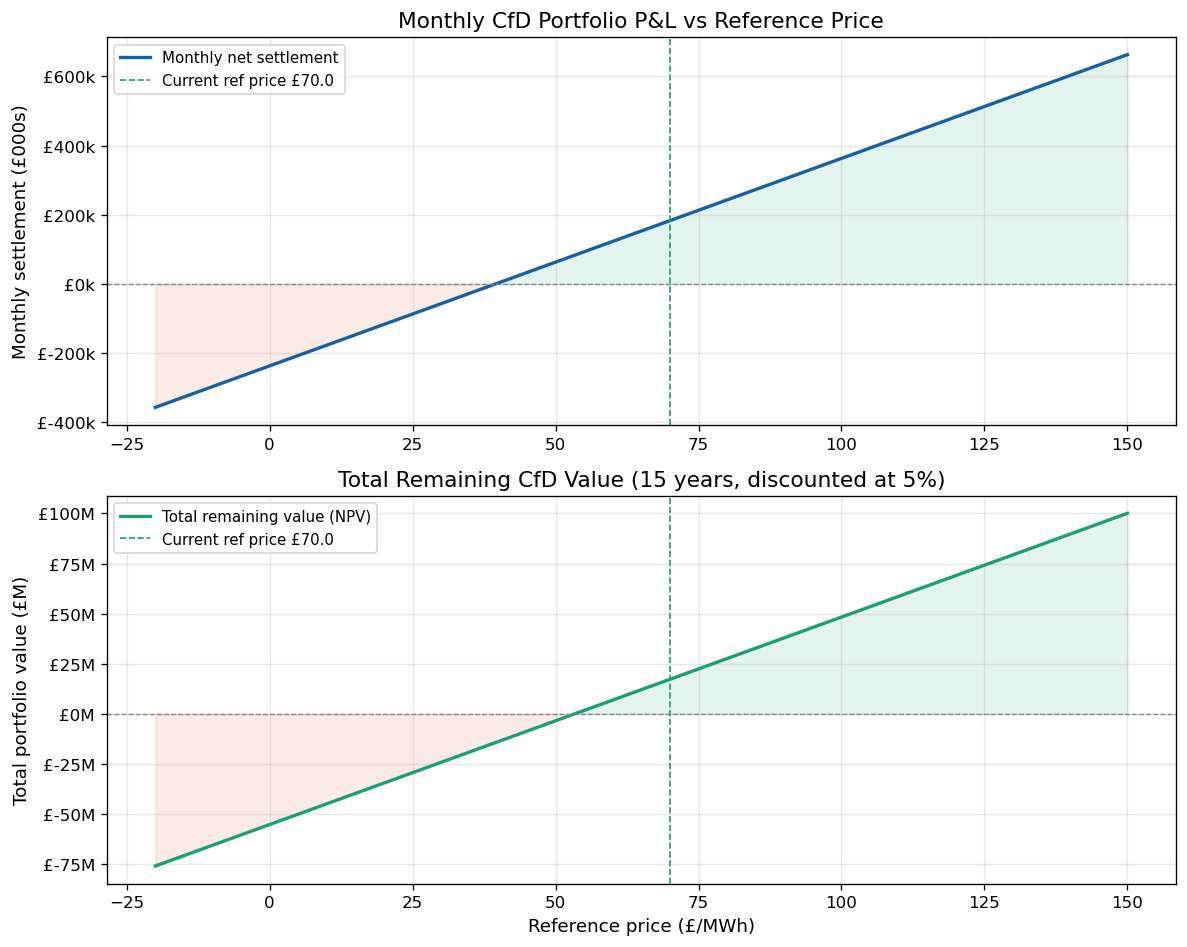

Chart saved as cfd_pnl_curve_with_tenor.png


In [5]:
# Sweep reference prices — the 'P&L curve'
# 
# CRITICAL LIMITATION: This analysis assumes PERFECT CORRELATION
# between all reference prices. In reality:
#   - Wind, solar, and gas prices move differently
#   - Different delivery periods have different prices
#   - This creates BASIS RISK that this simplified model ignores
#
# For a more sophisticated analysis, one would:
#   1. Model each contract's reference price separately
#   2. Estimate correlation between different price drivers
#   3. Run Monte Carlo simulations with correlated shocks
#
# However, for understanding basic portfolio sensitivity and
# comparing hedge strategies, this simplified approach is sufficient.


prices = np.linspace(-20, 150, 300)  

monthly_results = []
total_results = []

for ref in prices:
    monthly_net = sum(p.monthly_settlement(ref) for p in portfolio)
    total_net = sum(p.total_remaining_value(ref, discount_rate=0.05) for p in portfolio)
    monthly_results.append({'reference_price': ref, 'net_monthly_settlement': monthly_net})
    total_results.append({'reference_price': ref, 'net_total_value': total_net})

monthly_df = pd.DataFrame(monthly_results)
total_df = pd.DataFrame(total_results)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top chart: Monthly settlement
ax1.plot(monthly_df['reference_price'], monthly_df['net_monthly_settlement'] / 1000,
         color='#185FA5', linewidth=2, label='Monthly net settlement')
ax1.axhline(0, color='#888780', linewidth=0.8, linestyle='--')
ax1.axvline(REFERENCE_PRICE, color='#1D9E75', linewidth=1, linestyle='--', label=f'Current ref price £{REFERENCE_PRICE}')
ax1.fill_between(monthly_df['reference_price'], monthly_df['net_monthly_settlement']/1000, 0,
                where=monthly_df['net_monthly_settlement'] > 0, alpha=0.12, color='#1D9E75')
ax1.fill_between(monthly_df['reference_price'], monthly_df['net_monthly_settlement']/1000, 0,
                where=monthly_df['net_monthly_settlement'] < 0, alpha=0.12, color='#D85A30')
ax1.set_ylabel('Monthly settlement (£000s)', fontsize=11)
ax1.set_title('Monthly CfD Portfolio P&L vs Reference Price', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

# Bottom chart: Total remaining value
ax2.plot(total_df['reference_price'], total_df['net_total_value'] / 1e6,
         color='#1D9E75', linewidth=2, label='Total remaining value (NPV)')
ax2.axhline(0, color='#888780', linewidth=0.8, linestyle='--')
ax2.axvline(REFERENCE_PRICE, color='#1D9E75', linewidth=1, linestyle='--', label=f'Current ref price £{REFERENCE_PRICE}')
ax2.fill_between(total_df['reference_price'], total_df['net_total_value']/1e6, 0,
                where=total_df['net_total_value'] > 0, alpha=0.12, color='#1D9E75')
ax2.fill_between(total_df['reference_price'], total_df['net_total_value']/1e6, 0,
                where=total_df['net_total_value'] < 0, alpha=0.12, color='#D85A30')
ax2.set_xlabel('Reference price (£/MWh)', fontsize=11)
ax2.set_ylabel('Total portfolio value (£M)', fontsize=11)
ax2.set_title('Total Remaining CfD Value (15 years, discounted at 5%)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}M'))

plt.tight_layout()

plt.show()
print('Chart saved as cfd_pnl_curve_with_tenor.png')

In [6]:
# Cell 6: Hedge instruction output

def generate_hedge_instructions(portfolio: List[CfDPosition], total_monthly_load: float, ref_price: float):
    hedged_vol = sum(p.volume_mwh_per_month for p in portfolio)
    hedge_ratio = hedged_vol / total_monthly_load
    monthly_pnl = sum(p.monthly_settlement(ref_price) for p in portfolio)
    total_value = sum(p.total_remaining_value(ref_price) for p in portfolio)
    unhedged = total_monthly_load - hedged_vol

    print('=' * 65)
    print('HEDGE INSTRUCTION SUMMARY')
    print('=' * 65)
    print(f'  Reference price           : £{ref_price:.2f}/MWh')
    print(f'  Monthly load exposure     : {total_monthly_load:,.0f} MWh/month')
    print(f'  Hedged volume per month   : {hedged_vol:,.0f} MWh/month ({hedge_ratio:.1%})')
    print(f'  Unhedged exposure/month   : {unhedged:,.0f} MWh ({1-hedge_ratio:.1%})')
    print(f'  Monthly net settlement    : £{monthly_pnl:,.0f}')
    print(f'  Total remaining value     : £{total_value/1e6:,.1f}M (present value)')
    print()
    
    # Check if any contracts are expiring soon
    expiring_soon = [p for p in portfolio if p.months_remaining < 12]
    if expiring_soon:
        print('CONTRACTS EXPIRING WITHIN 12 MONTHS:')
        for p in expiring_soon:
            print(f'     - {p.name}: {p.months_remaining} months remaining')
        print()

    if hedge_ratio < 0.7:
        gap = total_monthly_load * 0.85 - hedged_vol
        print(f'  ACTION: Hedge ratio below 70%. Consider buying')
        print(f'          ~{gap:,.0f} MWh/month additional CfD volume')
        print(f'          to reach 85% target coverage.')
        print(f'  NOTE: For 15-year CfDs, this is a LONG-TERM commitment.')
    elif hedge_ratio > 1.05:
        excess = hedged_vol - total_monthly_load
        print(f'  ACTION: Over-hedged by {excess:,.0f} MWh/month ({hedge_ratio-1:.1%}).')
        print(f'          Consider unwinding or selling short')
        print(f'          {excess:,.0f} MWh/month to reduce basis risk.')
    else:
        print(f'  STATUS: Hedge ratio within target range. No action required.')
    
    print('=' * 65)

generate_hedge_instructions(portfolio, TOTAL_LOAD_MWH_PER_MONTH, REFERENCE_PRICE)

HEDGE INSTRUCTION SUMMARY
  Reference price           : £70.00/MWh
  Monthly load exposure     : 16,000 MWh/month
  Hedged volume per month   : 14,000 MWh/month (87.5%)
  Unhedged exposure/month   : 2,000 MWh (12.5%)
  Monthly net settlement    : £183,000
  Total remaining value     : £17.2M (present value)

  STATUS: Hedge ratio within target range. No action required.


## Model Limitations & Real-World Extensions 
The hedge instructions above are simplified for clarity. Below are the key assumptions and how I would handle them in practice.

### 1. Single Reference Price Assumption
**Our model assumes:** All contracts settle against the same price (£70/MWh).

**Reality:** Multiple reference prices exist:
- Different delivery periods (forward curve, not flat price)
- Different locations (North vs South UK prices vary £5-20/MWh)
- Different times of day (peak vs off-peak)
- Different products (day-ahead, intraday, balancing mechanism)

**Extension:** Replace `REFERENCE_PRICE` with forward curves and locational prices.

### 2. Perfect Correlation Assumption
**Our model assumes:** Wind, solar, and gas prices move perfectly together.

**Reality:** Prices have complex correlations:
- Wind and solar are correlated (both high on windy/sunny days)
- Gas has low correlation with renewables
- Extreme weather creates non-linear relationships

**Extension:** Implement correlated Monte Carlo simulations with a correlation matrix.

### 3. Linear Hedge Instructions
**Our model assumes:** Adding more CfD volume linearly improves hedge.

**Reality:** Multiple constraints apply:
- CfD auctions happen quarterly, not daily (timing constraints)
- Minimum contract sizes (typically 5,000-10,000 MWh)
- Counterparty credit limits per institution
- Market liquidity (can you actually buy that volume?)
- Price impact (buying changes the market price)

**Extension:** Add constraints for minimum trade sizes, credit limits, and execution costs.

### 4. Static Target Hedge Ratio
**Our model assumes:** 85% target applies always.

**Reality:** Dynamic targets based on:
- Time horizon (higher hedge for near-term, lower for far-term)
- Market volatility (hedge more when volatile)
- Regulatory changes (upcoming CfD auctions)
- Corporate risk appetite (varies by product)

**Extension:** Make hedge ratio targets a function of volatility and time.

### 5. No Counterparty Risk
**Our model assumes:** All CfDs have identical counterparty risk.

**Reality:** Different counterparties have different credit risks:
- UK Government (LCCC) = virtually risk-free
- Corporate PPAs = investment grade risk
- Banks = varies by institution

**Extension:** Add credit valuation adjustment (CVA) to discount cash flows by counterparty risk.

### 6. No Tenor/Maturity Matching
**Our model assumes:** All hedges last forever (or ignores expiry).

**Reality:** CfDs have finite lives (typically 15 years):
- Hedges expire at different times
- "Rolling" hedges is a real operational task
- Tenor mismatch creates basis risk

**Extension:** Track `months_remaining` per contract and alert when rolling is needed.

### 7. No Transaction Costs
**Our model assumes:** Buying/selling CfDs is free.

**Reality:** Significant costs apply:
- Brokerage fees (£0.10-0.50/MWh)
- Bid-ask spreads (typically 2-5% of contract value)
- Administrative costs (legal, credit checks, collateral)

**Extension:** Add transaction cost model (e.g., 1% of notional value).

### 8. Deterministic Discount Rate
**Our model assumes:** 5% discount rate is fixed.

**Reality:** Discount rates vary by:
- Asset type (government-backed = 3-4%, merchant = 8-10%)
- Time horizon (longer contracts = higher uncertainty)
- Market conditions (interest rates change)

**Extension:** Run sensitivity analysis on discount rate (3%, 5%, 7%, 10%).

### Summary: From Academic Model to Trading Desk Tool

| Dimension | Our Model | Production Model |
|-----------|-----------|----------------------|
| Reference price | Single flat price | Forward curves + locational prices |
| Correlation | Perfect | Historical correlation matrix |
| Hedge instruction | Volume only | Specific contract + counterparty + venue |
| Constraints | None | Credit limits, min trade size, liquidity |
| Risk metric | Hedge ratio | VaR, CVaR, stress testing |
| Time dimension | Static | Dynamic with rolling hedges |
| Counterparty | None | CVA, collateral requirements |
| Costs | Zero | Brokerage, bid-ask, admin |



